In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/data.csv')

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df = df.drop(columns=['id'])

df = df.dropna(axis=1, how='all')

print("Cleaned Dataset Shape:", df.shape)

print("\n--- Diagnosis Breakdown ---")
print(df['diagnosis'].value_counts())

Cleaned Dataset Shape: (569, 31)

--- Diagnosis Breakdown ---
diagnosis
B    357
M    212
Name: count, dtype: int64


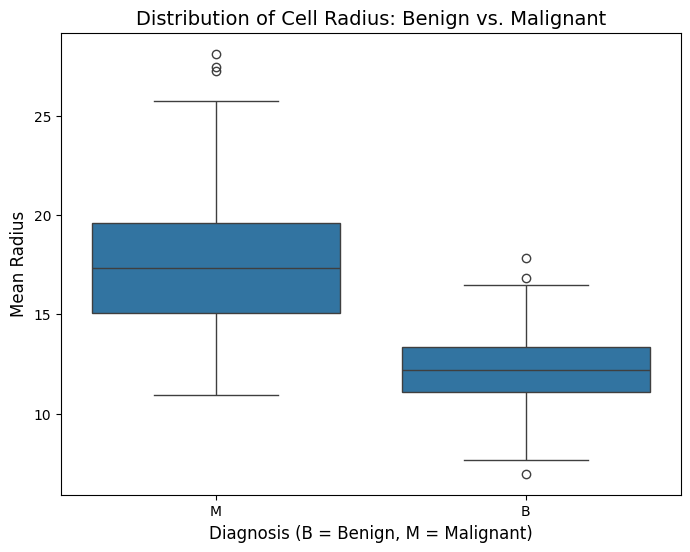

In [5]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='diagnosis', y='radius_mean', data=df)

plt.title('Distribution of Cell Radius: Benign vs. Malignant', fontsize=14)
plt.xlabel('Diagnosis (B = Benign, M = Malignant)', fontsize=12)
plt.ylabel('Mean Radius', fontsize=12)

plt.show()

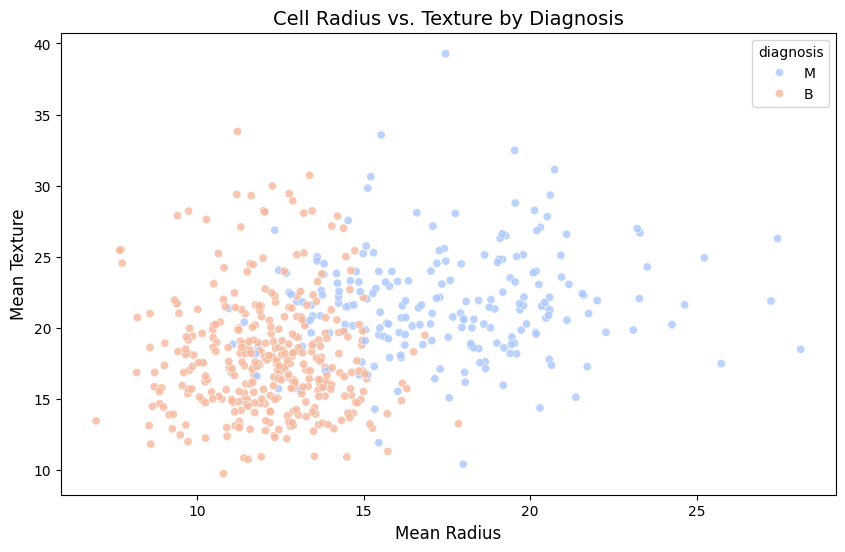

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='radius_mean', y='texture_mean', hue='diagnosis', data=df, palette='coolwarm', alpha=0.8)

plt.title('Cell Radius vs. Texture by Diagnosis', fontsize=14)
plt.xlabel('Mean Radius', fontsize=12)
plt.ylabel('Mean Texture', fontsize=12)

plt.show()

In [7]:
from scipy import stats

radius_m = df[df['diagnosis'] == 'M']['radius_mean']
radius_b = df[df['diagnosis'] == 'B']['radius_mean']

t_stat, p_value = stats.ttest_ind(radius_m, radius_b)

print("--- Significance Test Results: Cell Radius ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value}")

if p_value < 0.05:
    print("\nConclusion: Reject the Null Hypothesis. The difference is statistically significant.")
else:
    print("\nConclusion: Fail to reject the Null Hypothesis. The difference is not significant.")

--- Significance Test Results: Cell Radius ---
T-Statistic: 25.4358
P-Value: 8.465940572262422e-96

Conclusion: Reject the Null Hypothesis. The difference is statistically significant.
